In [1]:
!pip install pingouin 
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 23.3.1
[notice] To update, run: python3.9 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 23.3.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


In [2]:
import os
import platform

import pandas as pd
import numpy as np
from gensim.models import KeyedVectors
from pingouin import ancova
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings

# RuntimeWarning 무시
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
os_system = platform.system() # 맥북은 Darwin, 윈도우는 Windows

# 현재 프로젝트 폴더 위치 지정. os.getcwd()는 지금 코드 실행하는 현 위치를 출력해줍니다.
research1_dir = os.getcwd()

# data/processed 폴더 위치 지정
processed_data_dir = research1_dir + ('\\data\\processed\\' if os_system == 'Windows' else '/data/processed/')

# boxplots 이미지 저장할 폴더 위치 지정
graph_image_dir = research1_dir + ('\\graph\\ancova' if os_system == 'Windows' else '/graph/ancova')
# 폴더 없으면 생성
os.makedirs(graph_image_dir, exist_ok=True)


In [5]:
# 테이블 읽어오기
similarity_data = pd.read_csv(processed_data_dir + 'similarity_coherence_with_words.csv', encoding='ISO-8859-1')
survey_data = pd.read_csv(processed_data_dir + 'survey_data.csv', encoding='ISO-8859-1')

# 더미변수 생성
survey_data['sex_Male'] = (survey_data['sex'] == 1).astype(int)
survey_data['sex_Female'] = (survey_data['sex'] == 2).astype(int)

# Age 정수형으로 형변환
survey_data['age'] = survey_data['age'].astype(int)
survey_data[0:5]

,ï»¿subject,age,sex,group_NA,sex_Male,sex_Female
0,1,21,1,1,1,0
1,2,19,2,1,0,1
2,3,24,1,2,1,0
3,4,22,1,2,1,0
4,5,19,2,1,0,1


In [6]:
merged_df = pd.concat([similarity_data, survey_data], axis=1)
merged_df[0:3]

,subject,tear1,tear2,tear3,tear4,tear5,tear6,tear7,tear8,tear9,...,coherence_family_family,coherence_mirror_family,coherence_abuse_family,coherence_family,ï»¿subject,age,sex,group_NA,sex_Male,sex_Female
0,1,sadness,depressed,coolness,annoyance,failure,upset,conflict,farewell,heartache,...,0.124880,0.112939,0.179049,0.156554,1,21,1,1,1,0
1,2,sadness,sob,sad ending,movie,helminth,bug,apple,fruit,melon,...,0.102523,0.155402,0.106785,0.108539,2,19,2,1,0,1
2,3,masterpiece,world,travel,carrier,airport,airplane,sky,cloud,happiness,...,0.134183,0.122304,0.105398,0.123205,3,24,1,2,1,0


## ANOVA 분석 및 boxplot

In [7]:
def plot_anova_boxplots(between, xticklabels):
    fig, axes = plt.subplots(2, 4, figsize=(21, 6), constrained_layout=True)
    plt.subplots_adjust(top=0.9, wspace=0.5, hspace=0.35)

    ax = axes.flatten()

    seed_words = ['tear', 'family', 'mirror', 'abuse']
    target_words = ['money', 'friend']
    
    i = 0
    for target in target_words:
        for seed in seed_words:
            # ANCOVA 실행
            ancova_result = ancova(data=merged_df, dv=f'coherence_{seed}_{target}', between=between, covar=['age', 'sex_Female', 'sex_Male'])
            p_value = ancova_result['p-unc'].tolist()[0]
            print(f"ANCOVA 분석결과 - seed: {seed}, target: {target}")
            print(ancova_result)
            print()

            # 각 그래프에 대한 설정
            sns.boxplot(x=between,
                        y=f'coherence_{seed}_{target}', 
                        data=merged_df,
                        width=0.15,
                        boxprops=dict(facecolor="None", edgecolor="black"),
                        medianprops=dict(color="red"),
                        ax=ax[i])
            ax[i].set_title("")
            ax[i].set_xlabel("")
            ax[i].set_ylabel("")

            if i in [0, 4]:
                ax[i].set_ylabel(f"Similarity with \"{target}\"" , fontsize= 15)
            if i in [0, 1, 2, 3]:
                ax[i].set_title(f'Seed word: {seed}' , fontsize= 15)
            ax[i].set(xticklabels=xticklabels)

            # p-value 텍스트 추가
            ax[i].text(0.5, 0.1, f'p = {round(p_value, 3)}', fontsize=12, ha='center')
            i += 1
    # 전체 그리드 이미지를 저장
    filepath =  (f'\\{graph_image_dir}\\ancova_boxplots_{between}.png' if os_system == 'Windows' else f'/{graph_image_dir}/ancova_boxplots_{between}.png')
    plt.savefig(filepath, dpi=300)

    # 화면에 그리드 이미지 표시
    plt.show()


ANCOVA 분석결과 - seed: tear, target: money
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.000593    1   0.913350  3.399397e-01  0.002811
1         age  0.000073    1   0.112388  7.376582e-01  0.000347
2  sex_Female  0.038192    1  58.864043  1.999637e-13  0.153747
3    sex_Male  0.048764    1  75.159448  2.117976e-16  0.188294
4    Residual  0.210216  324        NaN           NaN       NaN

ANCOVA 분석결과 - seed: family, target: money
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.003452    1   5.801941  1.656628e-02  0.017592
1         age  0.001054    1   1.771658  1.841129e-01  0.005438
2  sex_Female  0.035380    1  59.462562  1.546191e-13  0.155067
3    sex_Male  0.037189    1  62.503401  4.214624e-14  0.161715
4    Residual  0.192778  324        NaN           NaN       NaN

ANCOVA 분석결과 - seed: mirror, target: money
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.000678    1   1.081818  2

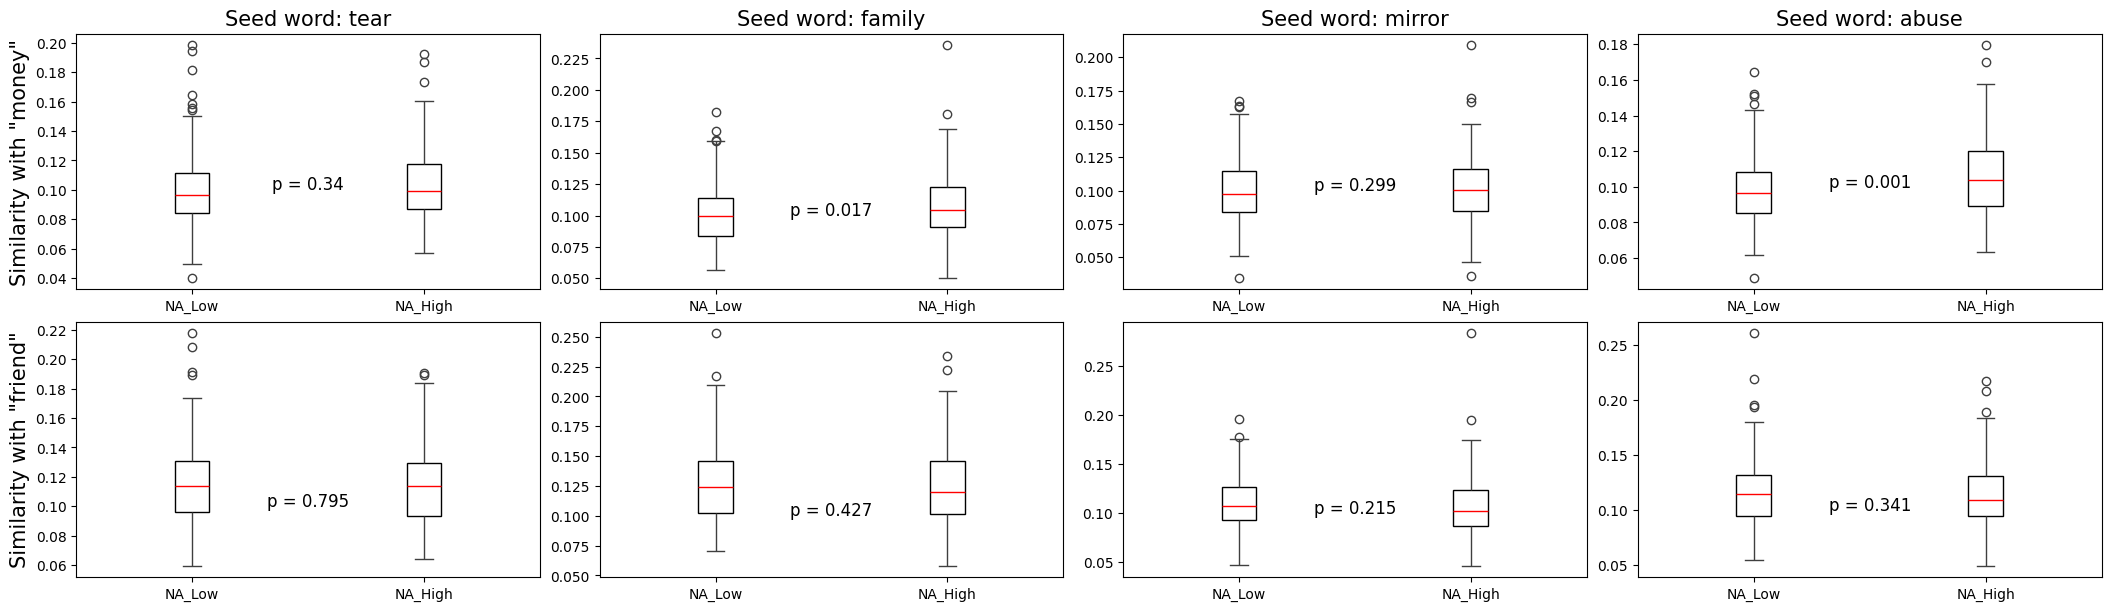

In [8]:
plot_anova_boxplots('group_NA', xticklabels=['NA_Low', 'NA_High'])